# Rolling two dice

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)

## Sample space for a pair of dice

In [2]:
def sample_space(n):
    z = np.zeros((n,n), np.uint64)
    for i in range(n):
        for j in range(n):
            z[i,j] += i + 1 + j + 1 
    return z

In [3]:
z = sample_space(6)

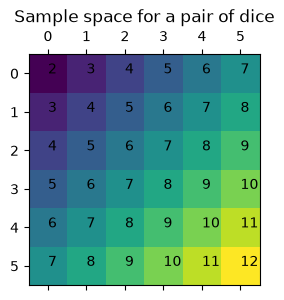

In [4]:
fig, axes = plt.subplots(figsize=(3,3))
axes.matshow(z)
for i in range(6):
    for j in range(6):
        axes.text(j, i, z[i,j])
plt.title("Sample space for a pair of dice")
plt.show()

## Roll a dice

In [5]:
def roll_dice():
    u = np.random.rand()
    res = 0
    for i in range(6):
        if i/6. <= u and u <= (i+1)/6.:
            res = i
    return res

In [6]:
def sample(n):
    return np.array([roll_dice() for _ in range(n)])

In [7]:
n = 100
x = sample(n)
y = sample(n)

In [8]:
# Histogram
def hist(x, m):
    y = np.zeros(m)
    for value in x:
        y[value] += 1
    return y / y.sum()

In [9]:
hx = hist(x, 6)
hy = hist(y, 6)

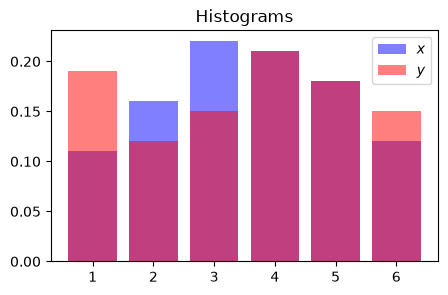

In [10]:
fig, axes = plt.subplots(figsize=(5, 3))
plt.bar([str(i) for i in range(1,7)], hx, color = "blue", alpha = .5, label = r"$x$")
plt.bar([str(i) for i in range(1,7)], hy, color = "red", alpha = .5, label = r"$y$")
plt.legend()
plt.title("Histograms")
plt.show()

# Dice sum

Let $Z = X+Y$.

$$P(Z = n) = P(X+Y=n) = \sum_{k=1}^{6}P({X=k} \cap {Y=n-k}) = \sum_{k=1}^{6} P(X=k)P(Y=n-k)$$

In [11]:
def compute_prob(hx, hy):
    # [2..12] that is 11
    p = np.zeros(11)
    for i in range(6):
        for j in range(6):
            p[i+j] += hx[i] * hy[j]
    return p

In [12]:
p = compute_prob(hx, hy)

In [13]:
z = x + y
hz = hist(z, 11)

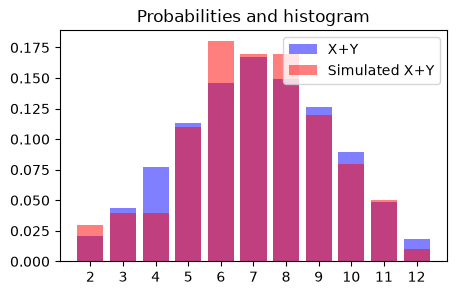

In [14]:
fig, axes = plt.subplots(figsize=(5, 3))
plt.bar([str(i) for i in range(2, 13)], p, color = "blue", alpha=.5, label = "X+Y")
plt.bar([str(i) for i in range(2, 13)], hz, color = "red", alpha = .5, label = "Simulated X+Y")
plt.legend()
plt.title("Probabilities and histogram")
plt.show()

## Large $n$

In [15]:
n = 100000

In [16]:
x = sample(n)
y = sample(n)

In [17]:
hx = hist(x, 6)
hy = hist(y, 6)

In [18]:
p = compute_prob(hx, hy)

In [19]:
z = x + y
hz = hist(z, 11)

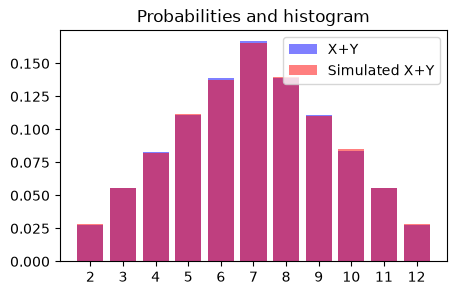

In [20]:
fig, axes = plt.subplots(figsize=(5, 3))
plt.bar([str(i) for i in range(2, 13)], p, color = "blue", alpha=.5, label = "X+Y")
plt.bar([str(i) for i in range(2, 13)], hz, color = "red", alpha = .5, label = "Simulated X+Y")
plt.legend()
plt.title("Probabilities and histogram")
plt.show()